# Mutang: Jacobian-Guided Uniform Mutation for AMP Optimization

This notebook demonstrates and analyses the **Mutang** method (`ProteinMutangUniformMutation`),
which uses the decoder Jacobian of a VAE (HydrAMP) to propose amino-acid substitutions in
antimicrobial peptides.

**Method summary:**
1. Pick a parent peptide from the elite pool (greedy / top-k)
2. Encode the peptide to latent space via the VAE encoder
3. Compute the Jacobian of the decoder (softmax probabilities) w.r.t. the latent vector
4. Run SVD on the Jacobian to get significant tangent-space directions
5. Map directions to per-position token substitution proposals
6. Uniformly sample one (position, new_token) pair that differs from the current sequence
7. Repeat steps 2-6 for `n_mutations` sequential mutation steps
8. Evaluate the mutant with the black-box fitness function (APEX MIC predictor)

In [1]:
import numpy as np
import torch
from transformers import AutoModel, AutoTokenizer

/home/pszmk/Latent-Anti-Microbial-Peptides-LAMP/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load HydrAMP model from Hugging Face Hub

In [2]:
HF_MODEL_REPO = "pszmk/hydramp"
HF_TOKENIZER_REPO = "pszmk/hydramp-aa-tokenizer"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained(HF_TOKENIZER_REPO, trust_remote_code=True)
model = AutoModel.from_pretrained(HF_MODEL_REPO, trust_remote_code=True)
model = model.to(DEVICE)
model.eval()

print(f"Device: {DEVICE}")
print(f"Model config: sequence_length={model.config.sequence_length}, vocab_size={model.config.vocab_size}")
print(f"Latent dim: {model.config.latent_dim}")

Device: cuda
Model config: sequence_length=25, vocab_size=21
Latent dim: 64


## 2. Define encode / decode helpers

In [3]:
SEQ_LEN = int(model.config.sequence_length)
VOCAB_SIZE = int(model.config.vocab_size)
LATENT_DIM = int(model.config.latent_dim)

ALPHABET = [tokenizer.convert_ids_to_tokens(i) for i in range(VOCAB_SIZE)]
CHAR_TO_ID = {ch: i for i, ch in enumerate(ALPHABET) if ch != ""}

print(f"Alphabet ({len(ALPHABET)} tokens): {ALPHABET}")


def tokenize_sequence(seq: str) -> torch.Tensor:
    """Tokenize a peptide string to model input_ids [1, SEQ_LEN]."""
    batch = tokenizer(
        seq,
        add_special_tokens=False,
        return_tensors="pt",
        padding="max_length",
        max_length=SEQ_LEN,
        truncation=False,
    )
    return batch["input_ids"].to(DEVICE).long()


def encode(input_ids: torch.Tensor) -> torch.Tensor:
    """Encode input_ids [batch, SEQ_LEN] -> latent mean [batch, LATENT_DIM]."""
    with torch.no_grad():
        mean, _log_std = model.encoder.encode(input_ids.to(DEVICE))
    return mean


def decode_logits(z: torch.Tensor) -> torch.Tensor:
    """Decode latent z [batch, LATENT_DIM] -> logits [batch, SEQ_LEN, VOCAB_SIZE]."""
    out = model.forward_latent_positions(z, condition=None, return_logits=True)
    return out.logits


def decode_probs_flat(z: torch.Tensor) -> torch.Tensor:
    """Decode latent z -> flattened probabilities [batch, SEQ_LEN * VOCAB_SIZE]."""
    logits = decode_logits(z)
    probs = torch.softmax(logits, dim=-1)
    return probs.reshape(z.shape[0], -1)


def ids_to_sequence(ids: np.ndarray, length: int | None = None) -> str:
    """Convert token id array back to a peptide string."""
    pad_id = tokenizer.pad_token_id
    chars = []
    for vid in ids.reshape(-1).tolist():
        if vid == pad_id:
            break
        chars.append(ALPHABET[vid])
    seq = "".join(chars)
    return seq[:length] if length else seq

Alphabet (21 tokens): ['<pad>', 'A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']


## 3. Compute the decoder Jacobian

The Jacobian of the decoder probability output w.r.t. the latent vector tells us
how each latent direction affects the token probabilities at each position.

In [4]:
from pep_compass_jr.utils import decoder_jacobian
from pep_compass_jr.tangent_space_mutation_proposer import substitutions_batch_from_jacobian

SEED_SEQUENCE = "FLYKWWIRIGRLKL"
print(f"Seed sequence: {SEED_SEQUENCE} (length {len(SEED_SEQUENCE)})")

input_ids = tokenize_sequence(SEED_SEQUENCE)
print(f"Input IDs shape: {input_ids.shape}")

z = encode(input_ids)
print(f"Latent z shape: {z.shape}")
print(f"Latent z (first 8 dims): {z[0, :8].cpu().numpy()}")

Seed sequence: FLYKWWIRIGRLKL (length 14)
Input IDs shape: torch.Size([1, 25])
Latent z shape: torch.Size([1, 64])
Latent z (first 8 dims): [-1.8529996   0.34533352 -1.6011696   0.76230025  0.24984646 -1.9246315
  0.6282935  -2.0039244 ]


In [5]:
JACOBIAN_MODE = "approx"
JACOBIAN_EPS = 1e-4

jac = decoder_jacobian(
    decode_probs_flat,
    z,
    JACOBIAN_MODE,
    {"jacobian_eps": JACOBIAN_EPS},
)
print(f"Jacobian shape: {jac.shape}  (batch, ambient={SEQ_LEN}*{VOCAB_SIZE}, latent={LATENT_DIM})")

Jacobian shape: torch.Size([1, 525, 64])  (batch, ambient=25*21, latent=64)


## 4. SVD of the Jacobian & substitution proposals

The SVD left singular vectors (U) represent significant directions in the
ambient (token probability) space. These are mapped to per-position candidate
substitutions via thresholding.

In [6]:
jac_np = jac.detach().cpu().numpy().astype(np.float64)

U, S, Vh = np.linalg.svd(jac_np[0], full_matrices=False)

print(f"U shape: {U.shape}  (ambient, min(ambient, latent))")
print(f"Singular values (top 20): {S[:20]}")
print(f"Number of singular values > 1e-3: {(S > 1e-3).sum()}")

U shape: (525, 64)  (ambient, min(ambient, latent))
Singular values (top 20): [2.21507786e-03 7.72982924e-04 4.76338209e-04 4.31978895e-04
 3.85505056e-04 1.36023068e-04 8.17980126e-05 2.61909519e-05
 1.88222842e-05 1.07605087e-05 6.79255252e-06 3.04428299e-06
 2.60010680e-06 1.91306081e-06 1.21051636e-06 1.03478596e-06
 9.12551499e-07 6.61048163e-07 6.13643529e-07 5.34533505e-07]
Number of singular values > 1e-3: 1


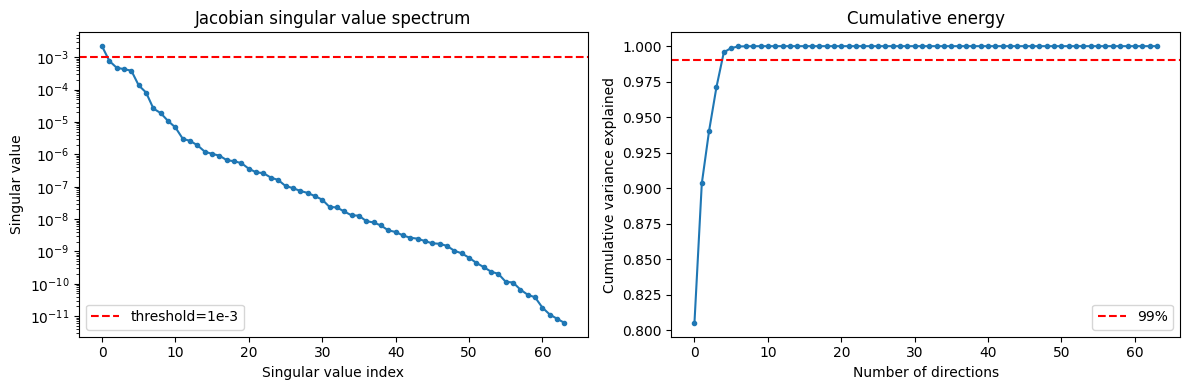

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].semilogy(S, "o-", markersize=3)
axes[0].axhline(1e-3, color="r", linestyle="--", label="threshold=1e-3")
axes[0].set_xlabel("Singular value index")
axes[0].set_ylabel("Singular value")
axes[0].set_title("Jacobian singular value spectrum")
axes[0].legend()

axes[1].plot(np.cumsum(S**2) / np.sum(S**2), "o-", markersize=3)
axes[1].set_xlabel("Number of directions")
axes[1].set_ylabel("Cumulative variance explained")
axes[1].set_title("Cumulative energy")
axes[1].axhline(0.99, color="r", linestyle="--", label="99%")
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Extract substitution proposals

In [8]:
DIRECTION_SIGNIFICANCE_THRESHOLD = 1e-3
MIN_NUMBER_OF_DIRECTIONS = 5
TOKEN_THRESHOLD = 0.1

substitutions = substitutions_batch_from_jacobian(
    jac,
    sequence_length=SEQ_LEN,
    vocab_size=VOCAB_SIZE,
    direction_significance_threshold=DIRECTION_SIGNIFICANCE_THRESHOLD,
    min_number_of_directions=MIN_NUMBER_OF_DIRECTIONS,
    token_threshold=TOKEN_THRESHOLD,
)[0]

print(f"Positions with proposed substitutions: {sorted(substitutions.keys())}")
print(f"Number of positions: {len(substitutions)}")
print()

pep_len = len(SEED_SEQUENCE)
for pos in sorted(substitutions.keys()):
    if pos < pep_len:
        current_aa = SEED_SEQUENCE[pos]
        proposed = [ALPHABET[vid] for vid in substitutions[pos]]
        novel = [aa for aa in proposed if aa != current_aa]
        print(f"  pos {pos:2d} (current={current_aa}): proposed={proposed}, novel={novel}")

Positions with proposed substitutions: [3, 6, 12]
Number of positions: 3

  pos  3 (current=K): proposed=['W'], novel=['W']
  pos  6 (current=I): proposed=['F', 'P'], novel=['F', 'P']
  pos 12 (current=K): proposed=['K', 'W'], novel=['W']


## 6. Run the Mutang solver (with a mock fitness function)

To quickly demonstrate the solver loop without requiring APEX weights,
we use a simple mock black box that scores sequences by hydrophobicity.

In [9]:
from poli.core.abstract_black_box import AbstractBlackBox
from poli.core.black_box_information import BlackBoxInformation
from amp_opt.mutang_solver import ProteinMutangUniformMutation

HYDROPHOBICITY = {
    "A": 1.8, "C": 2.5, "D": -3.5, "E": -3.5, "F": 2.8,
    "G": -0.4, "H": -3.2, "I": 4.5, "K": -3.9, "L": 3.8,
    "M": 1.9, "N": -3.5, "P": -1.6, "Q": -3.5, "R": -4.5,
    "S": -0.8, "T": -0.7, "V": 4.2, "W": -0.9, "Y": -1.3,
}


class HydrophobicityBlackBox(AbstractBlackBox):
    """Toy fitness: mean Kyte-Doolittle hydrophobicity (higher = more hydrophobic)."""

    def __init__(self, seq_len: int):
        super().__init__()
        self._info = BlackBoxInformation(
            "hydrophobicity_mock",
            seq_len,
            True, True, True,
            list(HYDROPHOBICITY.keys()),
        )

    def get_black_box_info(self) -> BlackBoxInformation:
        return self._info

    def _black_box(self, x: np.ndarray, context=None) -> np.ndarray:
        scores = []
        for row in x:
            seq = "".join(str(c) for c in row.tolist())
            score = np.mean([HYDROPHOBICITY.get(aa, 0.0) for aa in seq])
            scores.append(score)
        return np.array(scores, dtype=np.float64).reshape(-1, 1)

In [10]:
pep_len = len(SEED_SEQUENCE)

bb = HydrophobicityBlackBox(seq_len=pep_len)
x0 = np.array([list(SEED_SEQUENCE)], dtype=object)
y0 = bb(x0)

print(f"Seed: {SEED_SEQUENCE}")
print(f"Seed fitness (hydrophobicity): {y0[0, 0]:.4f}")


def tokenize_row(row: np.ndarray) -> torch.Tensor:
    seq = "".join(str(row.reshape(-1)[i]) for i in range(row.size))
    return tokenize_sequence(seq)


def decode_row(ids_1d: np.ndarray) -> np.ndarray:
    chars = [ALPHABET[int(vid)] for vid in ids_1d[:pep_len]]
    return np.array(chars, dtype=object)


def jacobian_batch_fn(z: torch.Tensor) -> torch.Tensor:
    return decoder_jacobian(
        decode_probs_flat,
        z,
        JACOBIAN_MODE,
        {"jacobian_eps": JACOBIAN_EPS},
    )

Seed: FLYKWWIRIGRLKL
Seed fitness (hydrophobicity): 0.2071


In [11]:
solver = ProteinMutangUniformMutation(
    black_box=bb,
    x0=x0,
    y0=y0,
    encode=encode,
    jacobian_batch_fn=jacobian_batch_fn,
    sequence_length=SEQ_LEN,
    vocab_size=VOCAB_SIZE,
    n_mutations=1,
    top_k=1,
    greedy=True,
    batch_size=1,
    alphabet=ALPHABET,
    tokenize_row=tokenize_row,
    decode_row=decode_row,
    mutable_model_prefix_len=pep_len,
)

In [12]:
N_ITERATIONS = 100

fitness_history = [float(y0[0, 0])]
best_history = [float(y0[0, 0])]
sequence_history = [SEED_SEQUENCE]

for i in range(N_ITERATIONS):
    x_new, y_new = solver.step()
    seq_new = "".join(str(c) for c in x_new[0].tolist())
    fitness_history.append(float(y_new[0, 0]))
    best_so_far = float(solver.get_best_performance()[0])
    best_history.append(best_so_far)
    sequence_history.append(seq_new)

best_x = solver.get_best_solution(top_k=1)
best_seq = "".join(str(c) for c in best_x[0].tolist())
best_fit = float(solver.get_best_performance()[0])

print(f"\nAfter {N_ITERATIONS} iterations:")
print(f"  Best sequence: {best_seq}")
print(f"  Best fitness:  {best_fit:.4f}")
print(f"  Seed fitness:  {float(y0[0, 0]):.4f}")
print(f"  Improvement:   {best_fit - float(y0[0, 0]):.4f}")


After 100 iterations:
  Best sequence: FLYWWWIRIGRLWL
  Best fitness:  0.6357
  Seed fitness:  0.2071
  Improvement:   0.4286


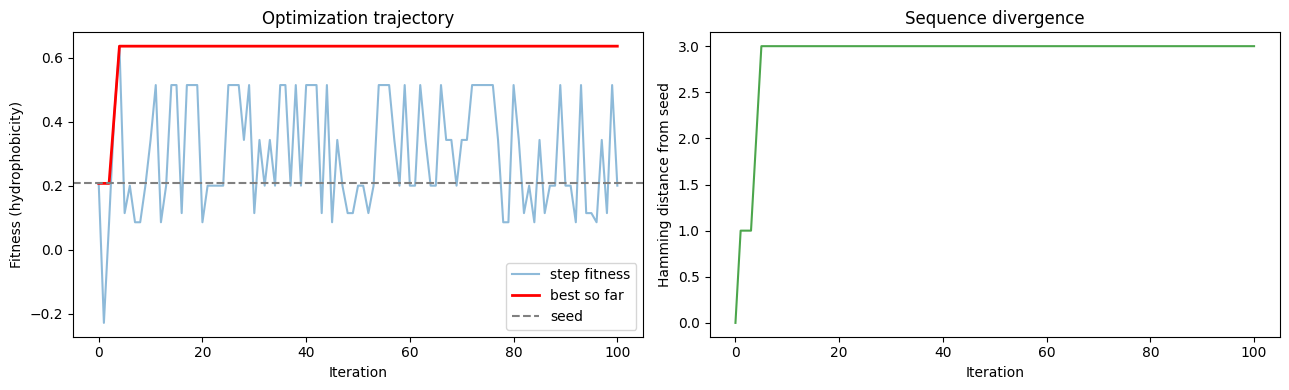

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(fitness_history, alpha=0.5, label="step fitness")
axes[0].plot(best_history, "r-", linewidth=2, label="best so far")
axes[0].axhline(float(y0[0, 0]), color="gray", linestyle="--", label="seed")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Fitness (hydrophobicity)")
axes[0].set_title("Optimization trajectory")
axes[0].legend()

hamming = [
    sum(a != b for a, b in zip(SEED_SEQUENCE, seq[:pep_len]))
    for seq in sequence_history
]
axes[1].plot(hamming, "g-", alpha=0.7)
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Hamming distance from seed")
axes[1].set_title("Sequence divergence")

plt.tight_layout()
plt.show()

## 7. Analyse mutation patterns

Which positions get mutated most often? What substitutions does the Jacobian favour?

In [14]:
from collections import Counter

mutation_positions = Counter()
mutation_types = Counter()

for i in range(1, len(sequence_history)):
    prev = sequence_history[i - 1]
    curr = sequence_history[i]
    for pos, (a, b) in enumerate(zip(prev[:pep_len], curr[:pep_len])):
        if a != b:
            mutation_positions[pos] += 1
            mutation_types[f"{a}{pos}{b}"] += 1

print("Most mutated positions:")
for pos, count in mutation_positions.most_common(10):
    print(f"  pos {pos:2d} ({SEED_SEQUENCE[pos]}): {count} mutations")

print("\nMost common substitutions:")
for mut, count in mutation_types.most_common(15):
    print(f"  {mut}: {count}")

Most mutated positions:
  pos  6 (I): 53 mutations
  pos  8 (I): 49 mutations
  pos  0 (F): 26 mutations
  pos 11 (L): 20 mutations
  pos  3 (K): 1 mutations
  pos 12 (K): 1 mutations

Most common substitutions:
  F8I: 14
  F0Y: 13
  Y0F: 13
  I8F: 12
  I8P: 11
  I6P: 10
  L11N: 10
  N11L: 10
  F6I: 9
  P8I: 8
  I6F: 8
  H6I: 7
  P6I: 7
  I6H: 5
  P8F: 3


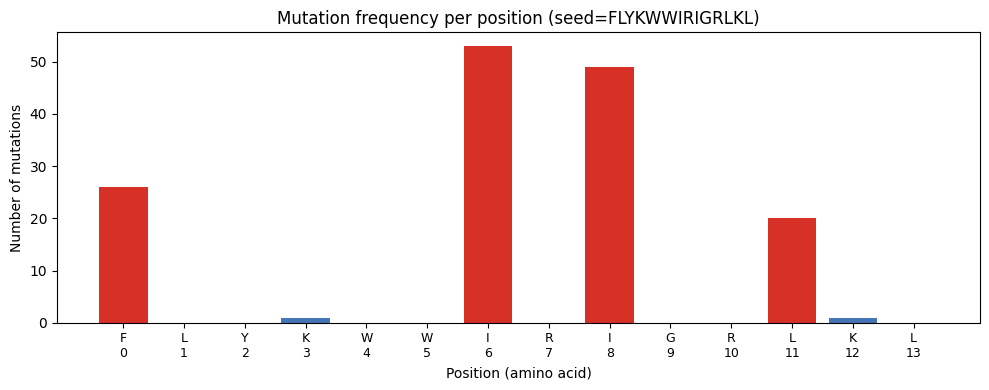

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))

positions = list(range(pep_len))
counts = [mutation_positions.get(p, 0) for p in positions]
colors = ["#d73027" if c > np.mean(counts) else "#4575b4" for c in counts]

bars = ax.bar(positions, counts, color=colors)
ax.set_xticks(positions)
ax.set_xticklabels([f"{SEED_SEQUENCE[i]}\n{i}" for i in positions], fontsize=9)
ax.set_xlabel("Position (amino acid)")
ax.set_ylabel("Number of mutations")
ax.set_title(f"Mutation frequency per position (seed={SEED_SEQUENCE})")
plt.tight_layout()
plt.show()

## 8. Visualise the Jacobian structure

The Jacobian rows (ambient = position x vocab) show which positions and tokens
are sensitive to latent perturbations.

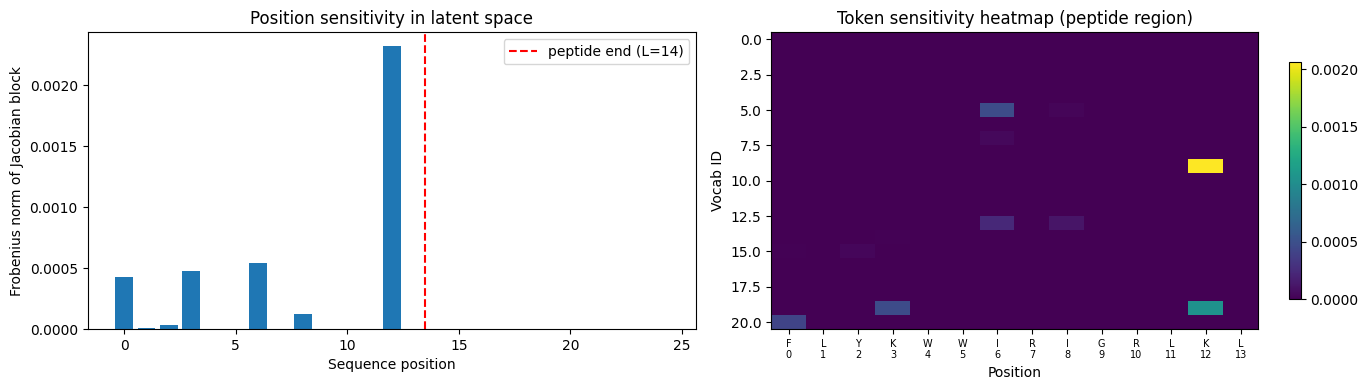

In [16]:
jac_2d = jac_np[0]  # (ambient, latent)
jac_reshaped = jac_2d.reshape(SEQ_LEN, VOCAB_SIZE, LATENT_DIM)

position_sensitivity = np.linalg.norm(jac_reshaped, axis=(1, 2))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(range(SEQ_LEN), position_sensitivity)
axes[0].axvline(pep_len - 0.5, color="red", linestyle="--", label=f"peptide end (L={pep_len})")
axes[0].set_xlabel("Sequence position")
axes[0].set_ylabel("Frobenius norm of Jacobian block")
axes[0].set_title("Position sensitivity in latent space")
axes[0].legend()

token_sensitivity = np.linalg.norm(jac_reshaped[:pep_len], axis=2)  # (pep_len, VOCAB_SIZE)
im = axes[1].imshow(token_sensitivity.T, aspect="auto", cmap="viridis")
axes[1].set_xlabel("Position")
axes[1].set_ylabel("Vocab ID")
axes[1].set_title("Token sensitivity heatmap (peptide region)")
axes[1].set_xticks(range(pep_len))
axes[1].set_xticklabels([f"{SEED_SEQUENCE[i]}\n{i}" for i in range(pep_len)], fontsize=7)
plt.colorbar(im, ax=axes[1], shrink=0.8)

plt.tight_layout()
plt.show()

## 9. Compare with random mutation baseline

Run the same number of iterations with uniform random mutations (no Jacobian guidance)
to see whether the tangent-space proposals give a meaningful advantage.

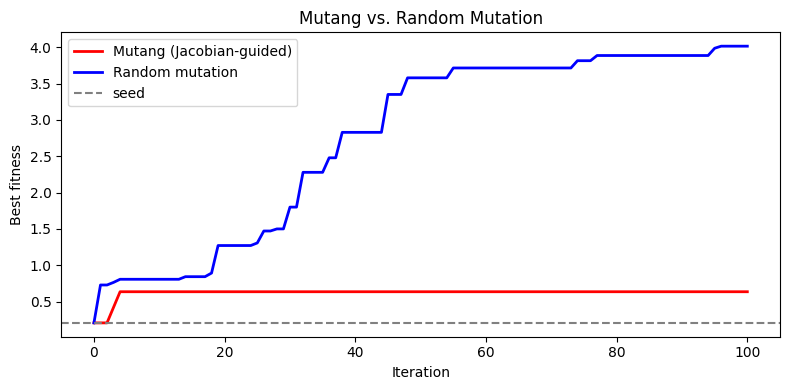

In [17]:
from amp_opt.random_mutation_solver import ProteinRandomMutation

bb_rand = HydrophobicityBlackBox(seq_len=pep_len)
x0_rand = np.array([list(SEED_SEQUENCE)], dtype=object)
y0_rand = bb_rand(x0_rand)

random_solver = ProteinRandomMutation(
    black_box=bb_rand,
    x0=x0_rand,
    y0=y0_rand,
    n_mutations=1,
    top_k=1,
    greedy=True,
    batch_size=1,
)

random_best_history = [float(y0_rand[0, 0])]
for _ in range(N_ITERATIONS):
    random_solver.step()
    random_best_history.append(float(random_solver.get_best_performance()[0]))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(best_history, "r-", linewidth=2, label="Mutang (Jacobian-guided)")
ax.plot(random_best_history, "b-", linewidth=2, label="Random mutation")
ax.axhline(float(y0[0, 0]), color="gray", linestyle="--", label="seed")
ax.set_xlabel("Iteration")
ax.set_ylabel("Best fitness")
ax.set_title("Mutang vs. Random Mutation")
ax.legend()
plt.tight_layout()
plt.show()

## 10. Multi-step mutations (`n_mutations > 1`)

With `n_mutations > 1`, the solver applies multiple sequential Jacobian-guided
mutations per candidate (recomputing the Jacobian after each mutation step).
This explores further from the parent in a single solver iteration.

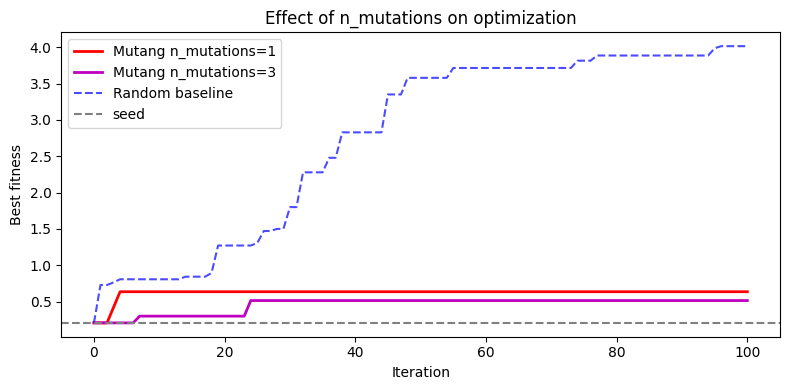

In [18]:
bb_multi = HydrophobicityBlackBox(seq_len=pep_len)
x0_multi = np.array([list(SEED_SEQUENCE)], dtype=object)
y0_multi = bb_multi(x0_multi)

solver_multi = ProteinMutangUniformMutation(
    black_box=bb_multi,
    x0=x0_multi,
    y0=y0_multi,
    encode=encode,
    jacobian_batch_fn=jacobian_batch_fn,
    sequence_length=SEQ_LEN,
    vocab_size=VOCAB_SIZE,
    n_mutations=3,
    top_k=1,
    greedy=True,
    batch_size=1,
    alphabet=ALPHABET,
    tokenize_row=tokenize_row,
    decode_row=decode_row,
    mutable_model_prefix_len=pep_len,
)

multi_best_history = [float(y0_multi[0, 0])]
for _ in range(N_ITERATIONS):
    solver_multi.step()
    multi_best_history.append(float(solver_multi.get_best_performance()[0]))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(best_history, "r-", linewidth=2, label="Mutang n_mutations=1")
ax.plot(multi_best_history, "m-", linewidth=2, label="Mutang n_mutations=3")
ax.plot(random_best_history, "b--", linewidth=1.5, alpha=0.7, label="Random baseline")
ax.axhline(float(y0[0, 0]), color="gray", linestyle="--", label="seed")
ax.set_xlabel("Iteration")
ax.set_ylabel("Best fitness")
ax.set_title("Effect of n_mutations on optimization")
ax.legend()
plt.tight_layout()
plt.show()

## 11. Tuning the substitution thresholds

The number of proposed substitutions depends on:
- `direction_significance_threshold`: minimum singular value to keep a tangent direction
- `min_number_of_directions`: floor on number of directions even if below threshold
- `token_threshold`: minimum absolute U-column entry to propose a token

Looser thresholds = more proposals (more exploration, less Jacobian fidelity).

  token_threshold=0.01: 3 positions, 7 total proposals
  token_threshold=0.05: 3 positions, 5 total proposals
  token_threshold=0.10: 3 positions, 5 total proposals
  token_threshold=0.20: 3 positions, 5 total proposals
  token_threshold=0.30: 3 positions, 5 total proposals
  token_threshold=0.50: 3 positions, 4 total proposals


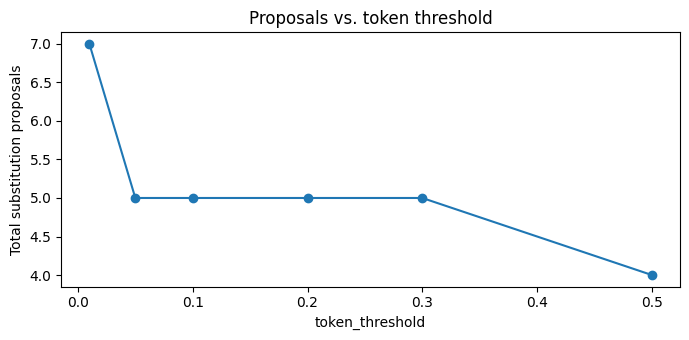

In [19]:
thresholds = [0.01, 0.05, 0.1, 0.2, 0.3, 0.5]
n_proposals_by_threshold = []

for thresh in thresholds:
    subst = substitutions_batch_from_jacobian(
        jac,
        sequence_length=SEQ_LEN,
        vocab_size=VOCAB_SIZE,
        direction_significance_threshold=DIRECTION_SIGNIFICANCE_THRESHOLD,
        min_number_of_directions=MIN_NUMBER_OF_DIRECTIONS,
        token_threshold=thresh,
    )[0]
    total_proposals = sum(len(v) for v in subst.values())
    n_proposals_by_threshold.append(total_proposals)
    print(f"  token_threshold={thresh:.2f}: {len(subst)} positions, {total_proposals} total proposals")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(thresholds, n_proposals_by_threshold, "o-")
ax.set_xlabel("token_threshold")
ax.set_ylabel("Total substitution proposals")
ax.set_title("Proposals vs. token threshold")
plt.tight_layout()
plt.show()

## Summary

The **Mutang** method leverages the geometry of the decoder manifold (via its Jacobian)
to restrict random mutations to a biologically-informed subspace. Key observations:

1. **The Jacobian captures meaningful structure** — most variance is concentrated in a
   low-dimensional subspace (few significant singular values).
2. **Substitution proposals are position-specific** — the SVD directions map to
   particular positions and tokens, not uniform across the sequence.
3. **Comparison with random mutation** shows whether the Jacobian guidance provides a
   search advantage (depends on the fitness landscape and model quality).
4. **Thresholds control exploration breadth** — tighter thresholds give fewer but
   higher-confidence proposals.

To run with the real APEX fitness function, replace `HydrophobicityBlackBox` with
`ApexBlackBox` (requires APEX model weights) or use the CLI:
```bash
uv sync --package lamp-amp-opt --extra hub
uv run --package lamp-amp-opt lamp-amp-opt --config src/amp_opt/src/amp_opt/configs/mutang_hydramp/all_log2.yaml
```